In [2]:
import numpy as np
import os
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns

from eval_utils import compare_aligned_data

In [3]:
data_dir = 'data'
label_dir = os.path.join(data_dir, 'int/lidar/lidar_by_site_32736_10m')
site_names = np.sort(os.listdir(label_dir))
site_names

array(['KaringaniMassingirDevNode', 'KaringaniSite01', 'KaringaniSite02',
       'KaringaniSite03', 'KaringaniSite04', 'KaringaniSite05',
       'KaringaniSite06', 'KaringaniSite07DevNodeB', 'KaringaniSite08',
       'KaringaniSite09', 'KaringaniSite10', 'KaringaniSite11DevNodeF',
       'KaringaniSite12', 'KaringaniSite13', 'KaringaniSite14',
       'KaringaniSite15', 'KaringaniSite16', 'KaringaniSite17',
       'KaringaniSite18', 'KaringaniSouthNorthDevNode',
       'KaringaniSouthSouthDevNode', 'KaringaniSungoloDevNode',
       'KaringaniVultureSite01', 'Mbilu'], dtype='<U26')

In [4]:
eval_dir = os.path.join(data_dir, 'existing_reference_data/eth_maps_per_site_10m')
fns_eval = os.listdir(eval_dir)

res_by_site_name_eth = {}
for site_name in site_names:
    tif_fns = [x for x in os.listdir(os.path.join(label_dir, site_name)) if x.endswith('.tif')]
    assert len(tif_fns) == 1
    tif_fn = tif_fns[0]
    label_fp = os.path.join(label_dir, site_name, tif_fn)
    
    with rasterio.open(label_fp) as f:
        labels = f.read()
        
    this_pred_fns = [x for x in fns_eval if site_name in x]
    assert len(this_pred_fns) == 1
    this_pred_fn = this_pred_fns[0]
    with rasterio.open(os.path.join(eval_dir,this_pred_fn)) as f:
        preds = f.read()
        
    res_by_site_name_eth[site_name] = compare_aligned_data(labels, preds, return_vals=True)

In [5]:
eval_dir = os.path.join(data_dir, 'existing_reference_data/glad_maps_per_site_10m')
fns_eval = os.listdir(eval_dir)

res_by_site_name_glad = {}
for site_name in site_names:
    tif_fns = [x for x in os.listdir(os.path.join(label_dir, site_name)) if x.endswith('.tif')]
    assert len(tif_fns) == 1
    tif_fn = tif_fns[0]
    label_fp = os.path.join(label_dir, site_name, tif_fn)
    
    with rasterio.open(label_fp) as f:
        labels = f.read()
        
    this_pred_fns = [x for x in fns_eval if site_name in x]
    assert len(this_pred_fns) == 1
    this_pred_fn = this_pred_fns[0]
    with rasterio.open(os.path.join(eval_dir,this_pred_fn)) as f:
        preds = f.read()
        
    res_by_site_name_glad[site_name] = compare_aligned_data(labels, preds, return_vals=True)

In [6]:
len(site_names)

24

Text(0.5, 1.0, 'eth and glad map evaluated as predictions per cite')

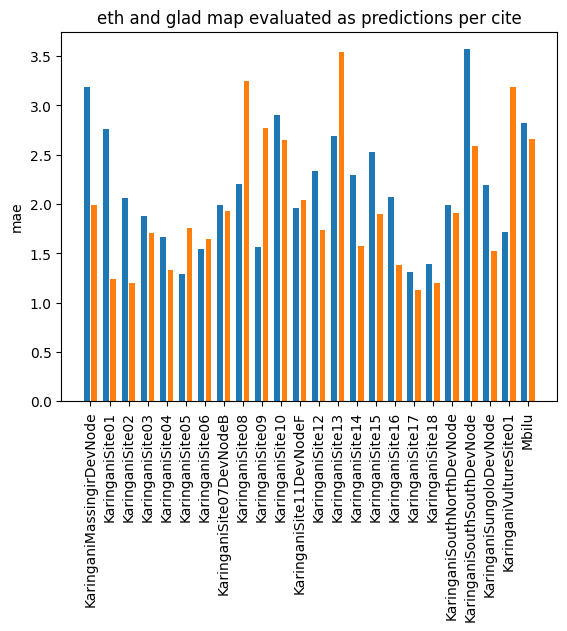

In [7]:
eval_metric = 'mae'
res_plot_eth = np.array([res_by_site_name_eth[x][eval_metric] for x in site_names])
res_plot_glad = np.array([res_by_site_name_glad[x][eval_metric] for x in site_names])

fig, ax = plt.subplots()
ax.bar(np.arange(len(site_names))-0.2, res_plot_eth, width=0.3, label='Lang et al.')
ax.bar(np.arange(len(site_names))+0.2, res_plot_glad,  width=0.3, label='GLAD')
ax.set_xticks(np.arange(len(site_names)));
ax.set_xticklabels(site_names, rotation=90);
ax.set_ylabel(eval_metric)
ax.set_title('eth and glad map evaluated as predictions per cite')


# Add in our results

In [8]:
res_by_site_name_ours = {}

for site_name in site_names:
    res_by_site_name_ours[site_name] = {}

for split in [0,1,2, 3]:
    results_dir_ours = f'experiment_results/predicted_maps/test_trainer/seed_10_split_{split}/'
    site_names_this_model = os.listdir(results_dir_ours)
    print(site_names_this_model)
    for site_name in site_names:
        if site_name in site_names_this_model:
            # get labels
            label_tif_fns = [x for x in os.listdir(os.path.join(label_dir, site_name)) if x.endswith('.tif')]
            assert len(tif_fns) == 1
            label_tif_fn = label_tif_fns[0]
            label_fp = os.path.join(label_dir, site_name, label_tif_fn)
            with rasterio.open(label_fp) as f:
                labels = f.read()

            this_pred_fns = [x for x in os.listdir(os.path.join(results_dir_ours, site_name)) if x.endswith('.tif')]
            assert len(this_pred_fns) == 1
            this_pred_fn = this_pred_fns[0]
            with rasterio.open(os.path.join(results_dir_ours,site_name, this_pred_fn)) as f:
                crop_pad = 40
                preds = f.read()[:,crop_pad:-crop_pad,crop_pad:-crop_pad]

            res_by_site_name_ours[site_name] = compare_aligned_data(labels, preds, return_vals=True)


['KaringaniSite02', 'KaringaniSite01', 'KaringaniSite11DevNodeF', 'KaringaniSite12', 'KaringaniSite07DevNodeB', 'KaringaniSite05']
['KaringaniSite14', 'KaringaniSungoloDevNode', 'KaringaniVultureSite01', 'KaringaniSite06', 'KaringaniSite03', 'KaringaniSite13']
['KaringaniSite18', 'KaringaniSouthSouthDevNode', 'KaringaniSite08', 'Mbilu', 'KaringaniSouthNorthDevNode', 'KaringaniSite10']
['KaringaniSite16', 'KaringaniSite17', 'KaringaniSite09', 'KaringaniSite04', 'KaringaniSite15', 'KaringaniMassingirDevNode']


In [9]:
# in case not all are done, plot those which are
site_names_plot = [x for (x,y) in res_by_site_name_ours.items() if  len(y) > 1] 
len(site_names_plot)

24

Text(0.5, 0, 'Lidar Site ID')

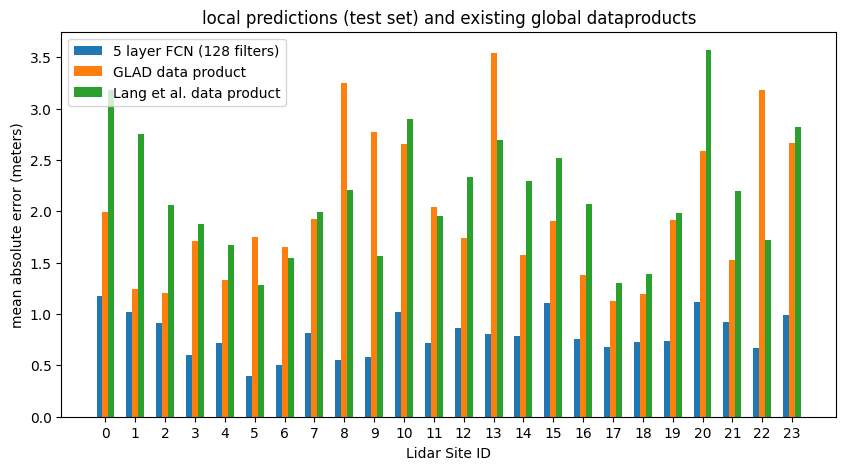

In [10]:
eval_metric = 'mae'
res_plot_ours = np.array([res_by_site_name_ours[x][eval_metric] for x in site_names_plot])
res_plot_eth = np.array([res_by_site_name_eth[x][eval_metric] for x in site_names_plot])
res_plot_glad = np.array([res_by_site_name_glad[x][eval_metric] for x in site_names_plot])

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(np.arange(len(site_names_plot))-0.2, res_plot_ours, width=0.2, label='5 layer FCN (128 filters)')
ax.bar(np.arange(len(site_names_plot))+0.0, res_plot_glad, width=0.2, label='GLAD data product')
ax.bar(np.arange(len(site_names_plot))+0.2, res_plot_eth, width=0.2, label='Lang et al. data product')

ax.set_xticks(np.arange(len(site_names_plot)));
#ax.set_xticklabels(site_names_plot, rotation=30, horizontalalignment='right');
ax.set_ylabel(eval_metric)
ax.set_title('local predictions (test set) and existing global dataproducts')
plt.legend()
plt.ylabel("mean absolute error (meters)")
plt.xlabel("Lidar Site ID")

In [11]:
site_names_plot[16]

'KaringaniSite16'

In [12]:
np.where(['16' in x for x in site_names_plot])

(array([16]),)

# Visualize

In [13]:
vis_site_ids = ['KaringaniSite12','KaringaniSouthNorthDevNode', 'KaringaniSite16']

In [29]:
def plot_aligned_data(labels, preds, vis, mask_nodata=False, nodata_val=-9999., pred_label='reference/predicted values'):
    if mask_nodata: 
        preds[preds == nodata_val] = None
        labels[labels == nodata_val] = None
    fig, ax = plt.subplots(1,3, figsize=(24,8))
    ax[0].imshow(labels, vmin=0, vmax=15, interpolation=None, cmap='Greens')
    p = ax[1].imshow(preds, vmin=0, vmax=15, interpolation=None, cmap='Greens')
    ax[2].imshow(vis,  interpolation=None)
    
    
    ax[0].set_title('CHM labels (10m)')
    ax[1].set_title(pred_label)
    ax[2].set_title('S2 image')
    plt.colorbar(p)
    for axis in ax:
        axis.axis('off')
        
    
    
    return ax
    

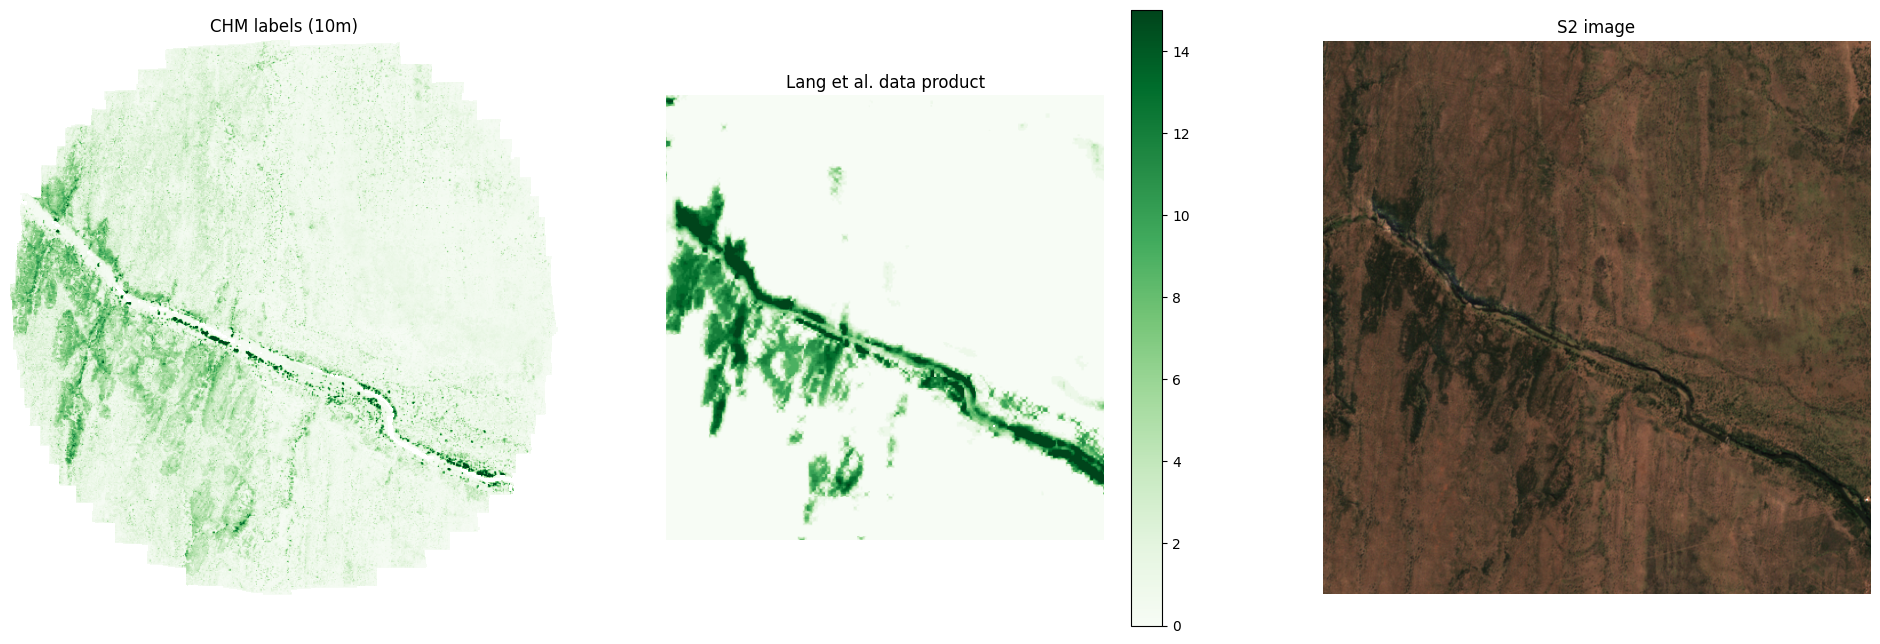

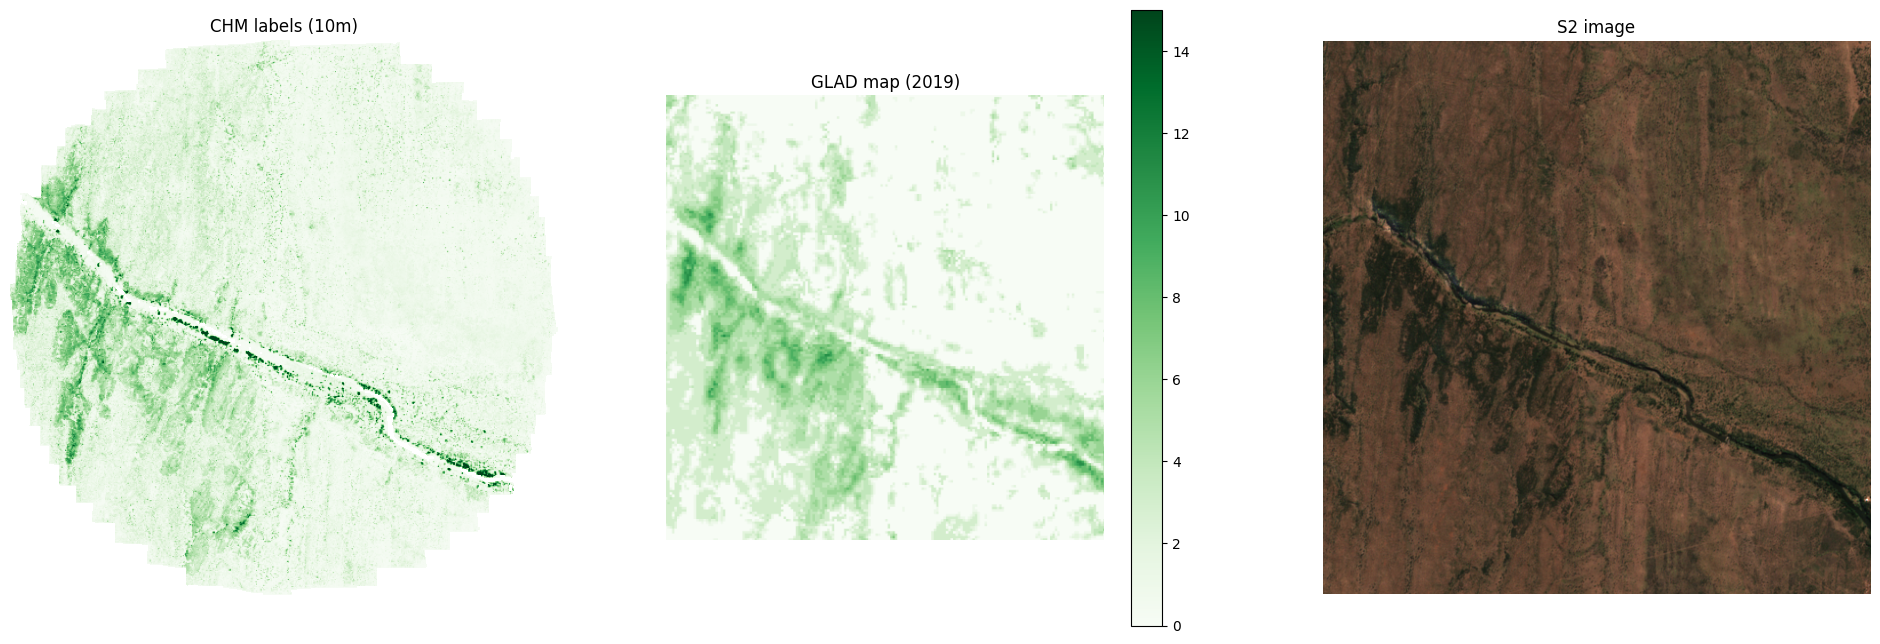

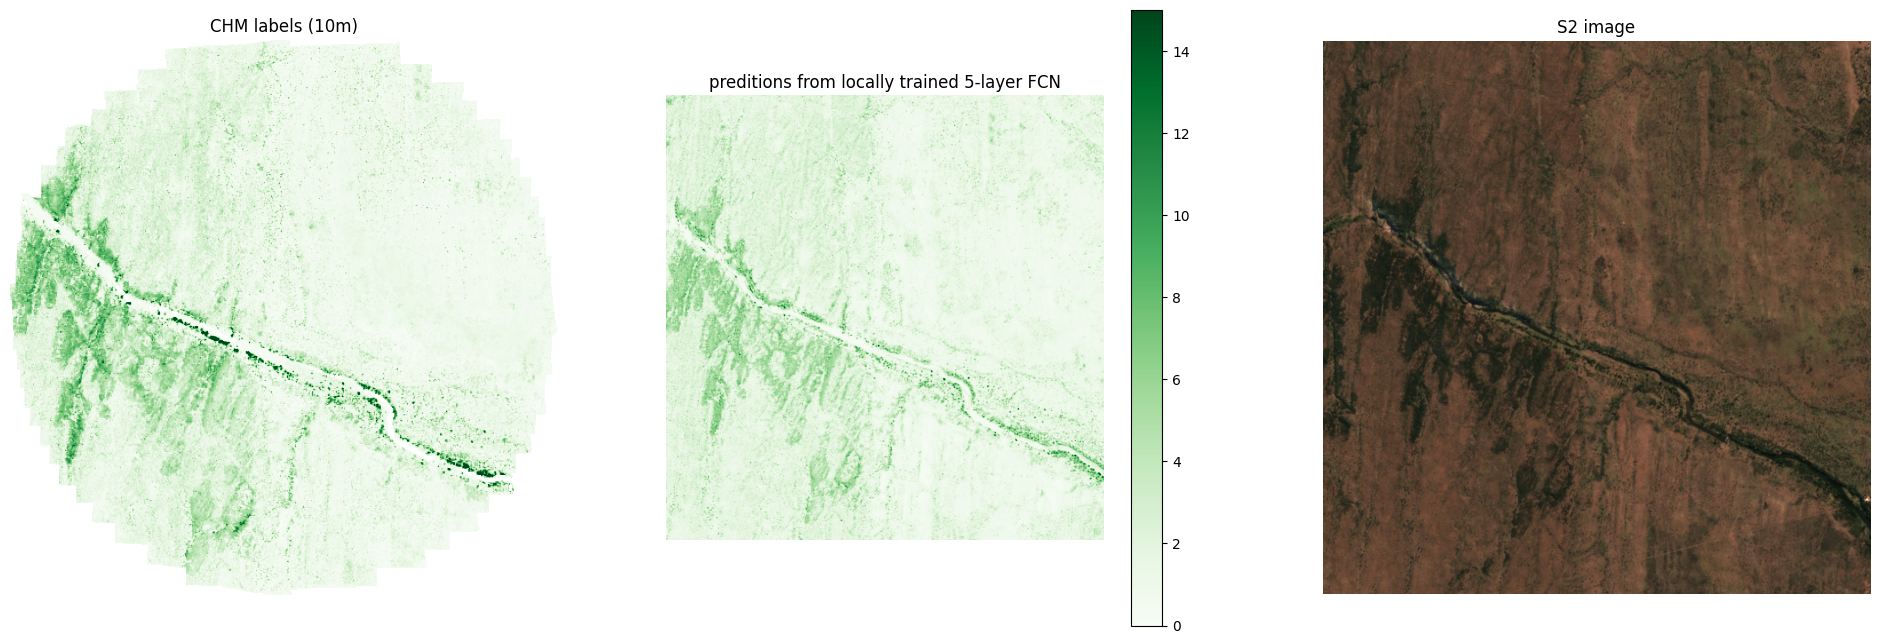

In [30]:
res_dicts = [res_by_site_name_eth, res_by_site_name_glad, res_by_site_name_ours]
res_types = ['Lang et al. data product', 'GLAD map (2019)', 'preditions from locally trained 5-layer FCN']

for eval_site_id in vis_site_ids[-1:]:
    # load tif
    
    for res_type, res_by_site_name in zip(res_types, res_dicts) :
        labels = res_by_site_name[eval_site_id]['labels'][0]
        preds = res_by_site_name[eval_site_id]['preds'][0]

        eval_input_dir = os.path.join(data_dir,f'int/sentinel/sentinel_by_site_32736_10m/{eval_site_id}')
        example_tif = [x for x in os.listdir(eval_input_dir) if x.endswith("TCI_10m.tif")][0]
        with rasterio.open(os.path.join(eval_input_dir, example_tif)) as f:
                vis = f.read().transpose(1,2,0)

        plot_aligned_data(labels, preds, vis = vis, mask_nodata=True, pred_label=res_type)
    



# Aggregate statistics

In [ ]:
# Get range of relative improvements across the sites

In [ ]:
eval_metric = 'mae'
res_ours = np.array([res_by_site_name_ours[x][eval_metric] for x in site_names_plot])
res_eth = np.array([res_by_site_name_eth[x][eval_metric] for x in site_names_plot])

print('compared to Lang et al.')
rel_improvement = (res_eth - res_ours) / res_eth
print(np.min(rel_improvement), np.max(rel_improvement))
print(np.mean(rel_improvement))

res_ours = np.array([res_by_site_name_ours[x][eval_metric] for x in site_names_plot])
res_glad = np.array([res_by_site_name_glad[x][eval_metric] for x in site_names_plot])

print('compared to GLAD')
rel_improvement = (res_glad - res_ours) / res_glad
print(np.min(rel_improvement), np.max(rel_improvement))
print(np.mean(rel_improvement))

In [54]:
eval_metric = 'rmse'
res_ours = np.array([res_by_site_name_ours[x][eval_metric] for x in site_names_plot])
res_eth = np.array([res_by_site_name_eth[x][eval_metric] for x in site_names_plot])

print('compared to Lang et al.')
rel_improvement = (res_eth - res_ours) / res_eth
print(np.min(rel_improvement), np.max(rel_improvement))
print(np.mean(rel_improvement))

res_ours = np.array([res_by_site_name_ours[x][eval_metric] for x in site_names_plot])
res_glad = np.array([res_by_site_name_glad[x][eval_metric] for x in site_names_plot])

print('compared to GLAD')
rel_improvement = (res_glad - res_ours) / res_glad
print(np.min(rel_improvement), np.max(rel_improvement))
print(np.mean(rel_improvement))

compared to Lang et al.
0.4481072 0.6465941
0.5742727
compared to GLAD
0.13307987 0.7499962
0.49630257
